<a href="https://colab.research.google.com/github/CaseySo/COGS109_FINAL_PROJECT/blob/main/work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond the lab: Making diabetes classification more accessible

Casey So and Lillian Tran



In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data

The data we used was found from the CDC from August 2021 to August 2023.

In [2]:
diabetes = pd.read_sas("DIQ_L.xpt", format="xport")
alcohol = pd.read_sas("ALQ_L.xpt", format="xport")
smoking = pd.read_sas("SMQ_L.xpt", format="xport")
demographics = pd.read_sas("DEMO_L.xpt", format="xport")
physical_activity = pd.read_sas("PAQ_L.xpt", format="xport")
body_measures = pd.read_sas("BMX_L.xpt", format="xport")
blood_pressure = pd.read_sas("BPXO_L.xpt", format="xport")

## Data Cleaning

### Diabetes

| Column    | Meaning                                    |
| --------- | ------------------------------------------ |
| `SEQN`    | Participant ID                             |
| `DIQ010`  | Doctor told you have diabetes              |
| `DID040`  | Age when first told you had diabetes       |
| `DIQ160`  | Ever told you have prediabetes             |
| `DIQ180`  | Had borderline diabetes                    |
| `DIQ050`  | Taking insulin now                         |
| `DID060`  | How long taking insulin                    |
| `DIQ060U` | Unit for insulin duration                  |
| `DIQ070`  | Taking diabetic pills to lower blood sugar |


For the purpose of this project we will be using:
| Variable | Why                                |
| -------- | ---------------------------------  |
| `DIQ010` | Those who have diabetes            |
| `DIQ160` | Those who have prediabetes         |
| `DIQ180` | TThose who have borderline diabetes|


In [3]:
diabetes

,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
11739,142306.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11740,142307.0,1.0,42.0,NaN,NaN,2.0,NaN,NaN,1.0
11741,142308.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
11742,142309.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN


In [4]:
def classify(row):
    if row["DIQ010"] == 1:
        return "diabetes"
    elif row["DIQ160"] == 1 or row["DIQ180"] == 1:
        return "borderline"
    else:
        return "none"

diabetes["target"] = diabetes.apply(classify, axis=1)
df = diabetes[["SEQN", "target"]]
df

,SEQN,target
0,130378.0,none
1,130379.0,borderline
2,130380.0,diabetes
3,130381.0,none
4,130382.0,none
...,...,...
11739,142306.0,none
11740,142307.0,diabetes
11741,142308.0,none
11742,142309.0,none


### Alcohol

| Column   | Meaning                                    |
| -------- | ------------------------------------------ |
| `SEQN`   | participant ID                             |
| `ALQ111` | had at least 12 alcohol drinks in lifetime |
| `ALQ121` | drinks per year/month/week                 |
| `ALQ130` | average drinks per drinking day            |
| `ALQ142` | binge drinking frequency                   |
| `ALQ270` | heavy drinking frequency                   |
| `ALQ280` | number of drinks                           |
| `ALQ151` | drank alcohol in past year                 |
| `ALQ170` | frequency of drinking                      |


For the purpose of this project we will be using:
| Variable | Why                                                 |
| -------- | --------------------------------------------------- |
| `ALQ151` | whether they drank in past year (baseline behavior) |
| `ALQ130` | drinks per occasion (intensity)                     |
| `ALQ170` | drinking frequency (how often)                      |



In [5]:
alcohol

,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,1.0,2.000000e+00,3.0,5.397605e-79,NaN,NaN,2.0,NaN
2,130380.0,1.0,1.000000e+01,1.0,5.397605e-79,NaN,NaN,2.0,NaN
3,130386.0,1.0,4.000000e+00,2.0,1.000000e+01,5.397605e-79,1.000000e+01,2.0,5.397605e-79
4,130387.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,2.0,NaN
...,...,...,...,...,...,...,...,...,...
6332,142305.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6333,142307.0,1.0,1.000000e+01,1.0,5.397605e-79,NaN,NaN,2.0,NaN
6334,142308.0,1.0,8.000000e+00,2.0,5.397605e-79,NaN,NaN,2.0,NaN
6335,142309.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
alc = alcohol[[
    "SEQN",
    "ALQ151",
    "ALQ130",
    "ALQ170"
]]
alc = alc.rename(columns={
    "ALQ151": "drank_past_year",
    "ALQ130": "drinks_per_occasion",
    "ALQ170": "drinking_frequency"
})
alc

,SEQN,drank_past_year,drinks_per_occasion,drinking_frequency
0,130378.0,NaN,NaN,NaN
1,130379.0,2.0,3.0,NaN
2,130380.0,2.0,1.0,NaN
3,130386.0,2.0,2.0,5.397605e-79
4,130387.0,2.0,NaN,NaN
...,...,...,...,...
6332,142305.0,NaN,NaN,NaN
6333,142307.0,2.0,1.0,NaN
6334,142308.0,2.0,2.0,NaN
6335,142309.0,NaN,NaN,NaN


### Smoking
| Variable   | Meaning                                                                   |
| ---------- | ------------------------------------------------------------------------- |
| `SMQ020`   | Smoked at least 100 cigarettes in lifetime (ever smoker indicator)        |
| `SMQ040`   | Current smoking status (every day / some days / not at all)               |
| `SMD641`   | Age first started smoking regularly                                       |
| `SMD650`   | Number of cigarettes smoked per day                                       |
| `SMD100MN` | Time since last smoked (in months)                                        |
| `SMQ621`   | Smoking exposure / household smoking-related question (context-dependent) |
| `SMD630`   | Additional smoking history detail (often conditional on prior answers)    |
| `SMAQUEX2` | Questionnaire version / routing variable (not behavioral)                 |

For the purpose of this project, we will be using:

| Variable | Why                                                         |
| -------- | ------------------------------------------------------------------------- |
| `SMQ020` | Captures whether someone has ever been a smoker (basic exposure signal)   |
| `SMQ040` | Distinguishes current smokers from past/never smokers (behavioral status) |
| `SMD650` | Measures smoking intensity, which is strongly related to health risk      |


In [7]:
smoking

,SEQN,SMQ020,SMQ040,SMD641,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2
0,130378.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
1,130379.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
2,130380.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,130384.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,130385.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...
9010,142305.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
9011,142307.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
9012,142308.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
9013,142309.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [8]:
smq = smoking[[
    "SEQN",
    "SMQ020",
    "SMQ040",
    "SMD650"
]]
smq = smq.rename(columns={
    "SMQ020": "ever_smoked_100_cigs",
    "SMQ040": "current_smoking_status",
    "SMD650": "cigs_per_day"
})
smq

,SEQN,ever_smoked_100_cigs,current_smoking_status,cigs_per_day
0,130378.0,1.0,3.0,NaN
1,130379.0,1.0,3.0,NaN
2,130380.0,2.0,NaN,NaN
3,130384.0,2.0,NaN,NaN
4,130385.0,2.0,NaN,NaN
...,...,...,...,...
9010,142305.0,2.0,NaN,NaN
9011,142307.0,1.0,3.0,NaN
9012,142308.0,2.0,NaN,NaN
9013,142309.0,2.0,NaN,NaN


### Demographics

| Variable   | Meaning                                    |
| ---------- | ------------------------------------------ |
| `SEQN`     | Participant ID (used to merge datasets)    |
| `SDDSRVYR` | Survey cycle / year group                  |
| `RIDSTATR` | Interview/exam status (2 = both completed) |
| `RIAGENDR` | Sex (1 = male, 2 = female)                 |
| `RIDAGEYR` | Age in years                               |
| `RIDAGEMN` | Age in months (used for children)          |
| `RIDRETH1` | Race/ethnicity (older coding)              |
| `RIDRETH3` | Race/ethnicity (updated coding, preferred) |
| `RIDEXMON` | Month of exam                              |
| `RIDEXAGM` | Age at exam in months (mostly for kids)    |
| `DMDHRGND` | Household reference person gender          |
| `DMDHRAGZ` | Household reference person age category    |
| `DMDHREDZ` | Education level (household ref person)     |
| `DMDHRMAZ` | Marital status (household ref person)      |
| `DMDHSEDZ` | Household education level                  |
| `WTINT2YR` | Interview sample weight                    |
| `WTMEC2YR` | Exam sample weight                         |
| `SDMVSTRA` | Stratum (survey design)                    |
| `SDMVPSU`  | PSU (survey design cluster)                |
| `INDFMPIR` | Income-to-poverty ratio                    |


For the purpose of this project, we will be using:
| Variable   | Why |
|------------|-----|
| SEQN       | Needed to merge datasets across NHANES files |
| RIDAGEYR   | Strongest predictor; diabetes risk increases with age |
| RIAGENDR   | Sex-based differences in diabetes risk |
| RIDRETH3   | Race/ethnicity associated with population-level risk differences |
| INDFMPIR   | Income-to-poverty ratio; proxy for socioeconomic status |


In [9]:
demographics

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,142306.0,12.0,2.0,1.0,9.0,NaN,2.0,2.0,1.0,111.0,...,1.0,3.0,3.0,3.0,NaN,11147.192563,13459.129019,176.0,1.0,2.01
11929,142307.0,12.0,2.0,2.0,49.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,69419.620456,64962.328962,181.0,1.0,NaN
11930,142308.0,12.0,2.0,1.0,50.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,32696.313477,44367.534132,183.0,2.0,1.95
11931,142309.0,12.0,2.0,1.0,40.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,30547.974564,46249.361849,176.0,1.0,3.11


In [10]:
demo = demographics[[
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "INDFMPIR"
]]
demo = demo.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH3": "race_ethnicity",
    "INDFMPIR": "income_ratio"
})
demo

,SEQN,age,sex,race_ethnicity,income_ratio
0,130378.0,43.0,1.0,6.0,5.00
1,130379.0,66.0,1.0,3.0,5.00
2,130380.0,44.0,2.0,2.0,1.41
3,130381.0,5.0,2.0,7.0,1.53
4,130382.0,2.0,1.0,3.0,3.60
...,...,...,...,...,...
11928,142306.0,9.0,1.0,2.0,2.01
11929,142307.0,49.0,2.0,4.0,NaN
11930,142308.0,50.0,1.0,2.0,1.95
11931,142309.0,40.0,1.0,2.0,3.11


### Physical Activity

| Variable  | Meaning                                               |
| --------- | ----------------------------------------------------- |
| `SEQN`    | Participant ID                                        |
| `PAD790Q` | Moderate recreational activity frequency              |
| `PAD790U` | Unit for PAD790Q (D = days, W = weeks, M = months)    |
| `PAD800`  | Minutes of moderate recreational activity             |
| `PAD810Q` | Vigorous recreational activity frequency              |
| `PAD810U` | Unit for PAD810Q                                      |
| `PAD820`  | Minutes of vigorous activity                          |
| `PAD680`  | Total physical activity (MET-minutes / summary score) |



For the purpose of this project, we will be using:
| Variable | Why                                    |
| -------- | -------------------------------------- |
| `PAD680` | best overall physical activity summary |
| `PAD800` | moderate activity intensity            |
| `PAD820` | vigorous activity intensity            |


In [11]:
physical_activity

,SEQN,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0
1,130379.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0
2,130380.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0
3,130384.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,60.0
4,130385.0,1.000000e+00,b'D',90.0,1.000000e+00,b'W',60.0,180.0
...,...,...,...,...,...,...,...,...
8148,142305.0,2.000000e+00,b'W',40.0,5.397605e-79,b'',NaN,480.0
8149,142307.0,3.000000e+00,b'W',15.0,5.397605e-79,b'',NaN,480.0
8150,142308.0,1.000000e+00,b'W',45.0,5.397605e-79,b'',NaN,600.0
8151,142309.0,2.000000e+00,b'D',15.0,5.397605e-79,b'',NaN,240.0


In [12]:
pa = physical_activity[[
    "SEQN",
    "PAD680",
    "PAD800",
    "PAD820"
]]
pa = pa.replace(5.397605e-79, np.nan)
pa = pa.rename(columns={
    "PAD680": "physical_activity_score",
    "PAD800": "moderate_activity_minutes",
    "PAD820": "vigorous_activity_minutes"
})
pa

,SEQN,physical_activity_score,moderate_activity_minutes,vigorous_activity_minutes
0,130378.0,360.0,45.0,45.0
1,130379.0,480.0,45.0,45.0
2,130380.0,240.0,20.0,NaN
3,130384.0,60.0,NaN,NaN
4,130385.0,180.0,90.0,60.0
...,...,...,...,...
8148,142305.0,480.0,40.0,NaN
8149,142307.0,480.0,15.0,NaN
8150,142308.0,600.0,45.0,NaN
8151,142309.0,240.0,15.0,NaN


### Body Measure

| Variable   | Meaning                                 |
| ---------- | --------------------------------------- |
| `SEQN`     | Participant ID                          |
| `BMDSTATS` | Exam status / measurement validity flag |
| `BMXWT`    | Weight (kg)                             |
| `BMXHT`    | Height (cm)                             |
| `BMXBMI`   | Body Mass Index                         |
| `BMXWAIST` | Waist circumference                     |
| `BMXHIP`   | Hip circumference                       |
| `BMXARMC`  | Arm circumference                       |
| `BMXLEG`   | Upper leg length                        |
| `BMXARML`  | Upper arm length                        |


For the purpose of this project, we will be using:
| Variable   | Why                                               |
| ---------- | ------------------------------------------------- |
| `BMXBMI`   | strongest single predictor of diabetes            |
| `BMXWAIST` | better indicator of visceral fat (very important) |
| `BMXWT`    | overall body mass signal                          |
| `BMXHT`    | helps contextualize weight                        |


In [13]:
body_measures

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,130378.0,1.0,86.9,NaN,NaN,NaN,NaN,NaN,179.5,NaN,...,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN
1,130379.0,1.0,101.8,NaN,NaN,NaN,NaN,NaN,174.2,NaN,...,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN
2,130380.0,1.0,69.4,NaN,NaN,NaN,NaN,NaN,152.9,NaN,...,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN
3,130381.0,1.0,34.3,NaN,NaN,NaN,NaN,NaN,120.1,NaN,...,NaN,NaN,25.4,NaN,23.4,NaN,70.4,NaN,NaN,NaN
4,130382.0,3.0,13.6,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8855,142306.0,1.0,25.3,NaN,NaN,NaN,NaN,NaN,128.0,NaN,...,32.0,NaN,25.0,NaN,19.0,NaN,57.7,NaN,NaN,NaN
8856,142307.0,3.0,NaN,1.0,NaN,NaN,NaN,NaN,143.8,NaN,...,NaN,1.0,34.0,NaN,35.4,NaN,NaN,1.0,NaN,1.0
8857,142308.0,1.0,79.3,NaN,NaN,NaN,NaN,NaN,173.3,NaN,...,41.8,NaN,40.0,NaN,30.6,NaN,98.4,NaN,97.7,NaN
8858,142309.0,1.0,81.9,NaN,NaN,NaN,NaN,NaN,179.1,NaN,...,44.0,NaN,40.0,NaN,30.8,NaN,96.0,NaN,103.3,NaN


In [14]:
bs = body_measures[[
    "SEQN",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT"
    ]]
bs = bs.rename(columns={
    "BMXBMI": "bmi",
    "BMXWAIST": "waist_measurement",
    "BMXWT": "weight",
    "BMXHT": "height"
})
bs

,SEQN,bmi,waist_measurement,weight,height
0,130378.0,27.0,98.3,86.9,179.5
1,130379.0,33.5,114.7,101.8,174.2
2,130380.0,29.7,93.5,69.4,152.9
3,130381.0,23.8,70.4,34.3,120.1
4,130382.0,NaN,NaN,13.6,NaN
...,...,...,...,...,...
8855,142306.0,15.4,57.7,25.3,128.0
8856,142307.0,NaN,NaN,NaN,143.8
8857,142308.0,26.4,98.4,79.3,173.3
8858,142309.0,25.5,96.0,81.9,179.1


### Blood Pressure

| Variable  | Meaning                                        |
| --------- | ---------------------------------------------- |
| `SEQN`    | Participant ID                                 |
| `BPAOARM` | Arm used for measurement (R = right, L = left) |
| `BPAOCSZ` | Cuff size used (1–4 scale)                     |
| `BPXOSY1/2/3` | Systolic blood pressure (1st/2nd/3rd reading)  |
| `BPXODI1/2/3` | Diastolic blood pressure (1st/2nd/3rd reading) |


For the purpose of this project, we will be using:
| Feature       | Meaning               |
| ------------- | --------------------- |
| systolic_avg  | average of BPXOSY1–3  |
| diastolic_avg | average of BPXODI1–3  |
| pulse_avg     | average of BPXOPLS1–3 |


In [15]:
blood_pressure

,SEQN,BPAOARM,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3
0,130378.0,b'R',4.0,135.0,98.0,131.0,96.0,132.0,94.0,82.0,79.0,82.0
1,130379.0,b'R',4.0,121.0,84.0,117.0,76.0,113.0,76.0,72.0,71.0,73.0
2,130380.0,b'R',4.0,111.0,79.0,112.0,80.0,104.0,76.0,84.0,83.0,77.0
3,130386.0,b'R',4.0,110.0,72.0,120.0,74.0,115.0,75.0,59.0,64.0,64.0
4,130387.0,b'R',4.0,143.0,76.0,136.0,74.0,145.0,78.0,80.0,80.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7796,142306.0,b'R',2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7797,142307.0,b'R',4.0,127.0,75.0,132.0,73.0,131.0,72.0,71.0,70.0,67.0
7798,142308.0,b'R',3.0,106.0,65.0,106.0,69.0,112.0,74.0,58.0,61.0,69.0
7799,142309.0,b'R',3.0,127.0,81.0,125.0,82.0,128.0,81.0,80.0,79.0,83.0


In [16]:
blood_pressure["systolic"] = blood_pressure[["BPXOSY1","BPXOSY2","BPXOSY3"]].mean(axis=1)
blood_pressure["diastolic"] = blood_pressure[["BPXODI1","BPXODI2","BPXODI3"]].mean(axis=1)
blood_pressure["pulse"] = blood_pressure[["BPXOPLS1","BPXOPLS2","BPXOPLS3"]].mean(axis=1)

bp = blood_pressure[["SEQN", "systolic", "diastolic", "pulse"]]
bp

,SEQN,systolic,diastolic,pulse
0,130378.0,132.666667,96.000000,81.000000
1,130379.0,117.000000,78.666667,72.000000
2,130380.0,109.000000,78.333333,81.333333
3,130386.0,115.000000,73.666667,62.333333
4,130387.0,141.333333,76.000000,79.000000
...,...,...,...,...
7796,142306.0,NaN,NaN,NaN
7797,142307.0,130.000000,73.333333,69.333333
7798,142308.0,108.000000,69.333333,62.666667
7799,142309.0,126.666667,81.333333,80.666667


## Merging

To create our "final" data set we are merging all of the columns that we picked out from the datasets above into one datatset merging on the SEQN, which it the participant identification number.

In [17]:
df = df.merge(demo, on="SEQN", how="left")
df = df.merge(alc, on="SEQN", how="left")
df = df.merge(smq, on="SEQN", how="left")
df = df.merge(pa, on="SEQN", how="left")
df = df.merge(bs, on="SEQN", how="left")
df = df.merge(bp, on="SEQN", how="left")
df

,SEQN,target,age,sex,race_ethnicity,income_ratio,drank_past_year,drinks_per_occasion,drinking_frequency,ever_smoked_100_cigs,...,physical_activity_score,moderate_activity_minutes,vigorous_activity_minutes,bmi,waist_measurement,weight,height,systolic,diastolic,pulse
0,130378.0,none,43.0,1.0,6.0,5.00,NaN,NaN,NaN,1.0,...,360.0,45.0,45.0,27.0,98.3,86.9,179.5,132.666667,96.000000,81.000000
1,130379.0,borderline,66.0,1.0,3.0,5.00,2.0,3.0,NaN,1.0,...,480.0,45.0,45.0,33.5,114.7,101.8,174.2,117.000000,78.666667,72.000000
2,130380.0,diabetes,44.0,2.0,2.0,1.41,2.0,1.0,NaN,2.0,...,240.0,20.0,NaN,29.7,93.5,69.4,152.9,109.000000,78.333333,81.333333
3,130381.0,none,5.0,2.0,7.0,1.53,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,23.8,70.4,34.3,120.1,NaN,NaN,NaN
4,130382.0,none,2.0,1.0,3.0,3.60,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.6,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11739,142306.0,none,9.0,1.0,2.0,2.01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,15.4,57.7,25.3,128.0,NaN,NaN,NaN
11740,142307.0,diabetes,49.0,2.0,4.0,NaN,2.0,1.0,NaN,1.0,...,480.0,15.0,NaN,NaN,NaN,NaN,143.8,130.000000,73.333333,69.333333
11741,142308.0,none,50.0,1.0,2.0,1.95,2.0,2.0,NaN,2.0,...,600.0,45.0,NaN,26.4,98.4,79.3,173.3,108.000000,69.333333,62.666667
11742,142309.0,none,40.0,1.0,2.0,3.11,NaN,NaN,NaN,2.0,...,240.0,15.0,NaN,25.5,96.0,81.9,179.1,126.666667,81.333333,80.666667


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

df = df.drop(columns=["SEQN"])

le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])

X = df.drop(columns=["target"])
y = df["target"]
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

## Visualizations

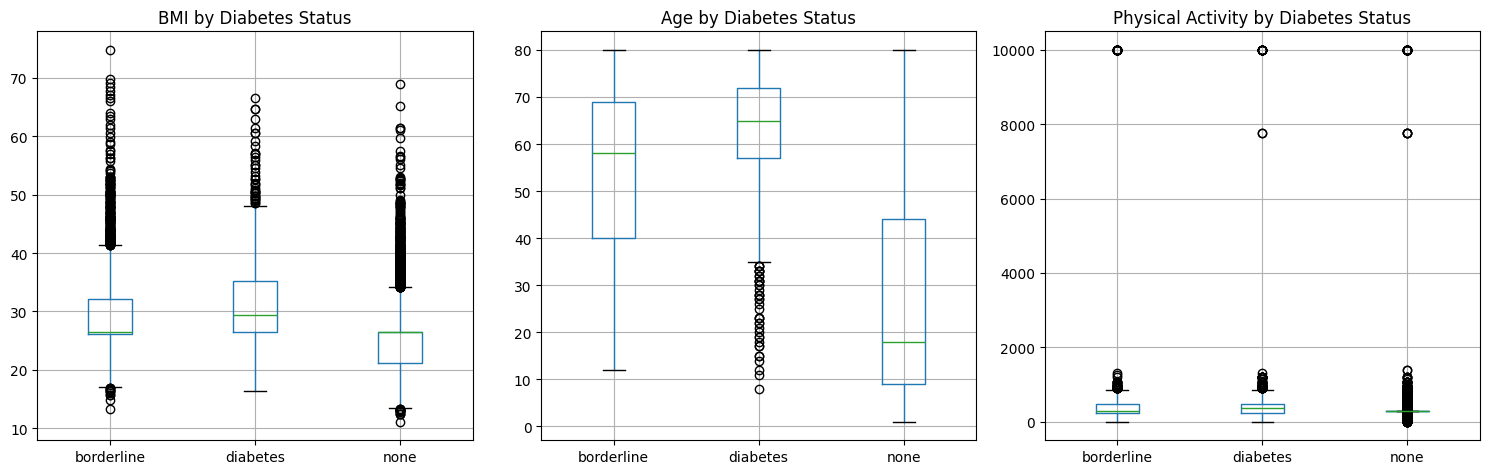

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Add target back for plotting
df_plot = X.copy()
df_plot["target"] = y.map({0: "borderline", 1: "diabetes", 2: "none"})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_plot.boxplot(column="bmi", by="target", ax=axes[0])
axes[0].set_title("BMI by Diabetes Status")
axes[0].set_xlabel("")

df_plot.boxplot(column="age", by="target", ax=axes[1])
axes[1].set_title("Age by Diabetes Status")
axes[1].set_xlabel("")

df_plot.boxplot(column="physical_activity_score", by="target", ax=axes[2])
axes[2].set_title("Physical Activity by Diabetes Status")
axes[2].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

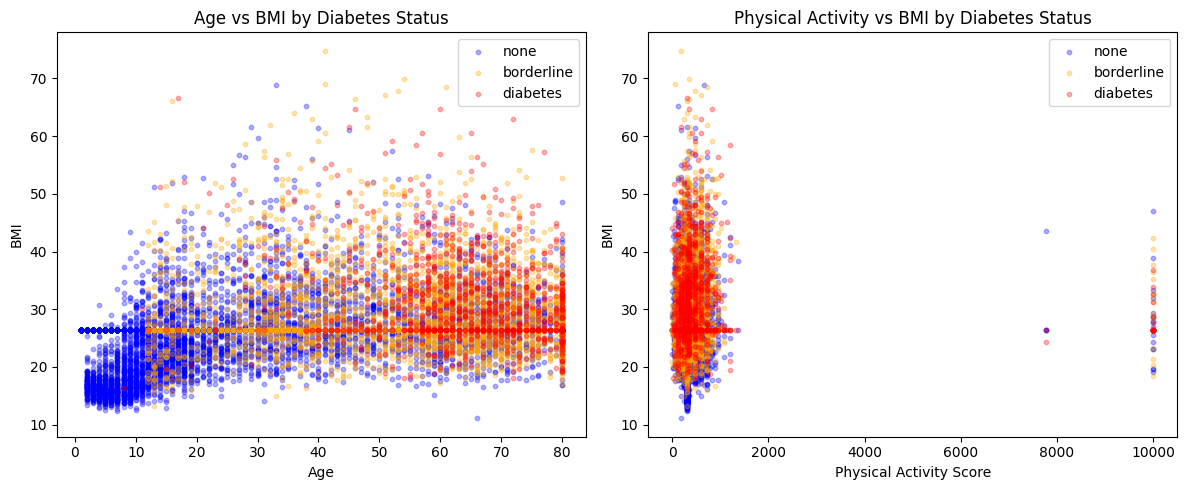

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {0: "orange", 1: "red", 2: "blue"}
labels = {0: "borderline", 1: "diabetes", 2: "none"}

for group in df_plot["target"].unique():
    subset = df_plot[df_plot["target"] == group]
    color_key = [k for k, v in labels.items() if v == group][0]
    axes[0].scatter(subset["age"], subset["bmi"],
                    label=group, alpha=0.3, s=10, color=colors[color_key])
    axes[1].scatter(subset["physical_activity_score"], subset["bmi"],
                    label=group, alpha=0.3, s=10, color=colors[color_key])

axes[0].set_xlabel("Age")
axes[0].set_ylabel("BMI")
axes[0].set_title("Age vs BMI by Diabetes Status")
axes[0].legend()

axes[1].set_xlabel("Physical Activity Score")
axes[1].set_ylabel("BMI")
axes[1].set_title("Physical Activity vs BMI by Diabetes Status")
axes[1].legend()

plt.tight_layout()
plt.show()

## Models

### PCA

- Principal Component Analysis is a dimensionality reduction technique that transforms the original variables into a smaller set of uncorrelated components that capture the most variation in the data

- Each component is a weighted combination of the original variables, ordered so that the first component explains the most variance, the second explains the next most, and so on

- We use it to explore whether our 20 predictor variables can be compressed without losing information, finding that 14 components are needed to explain 90% of the variance

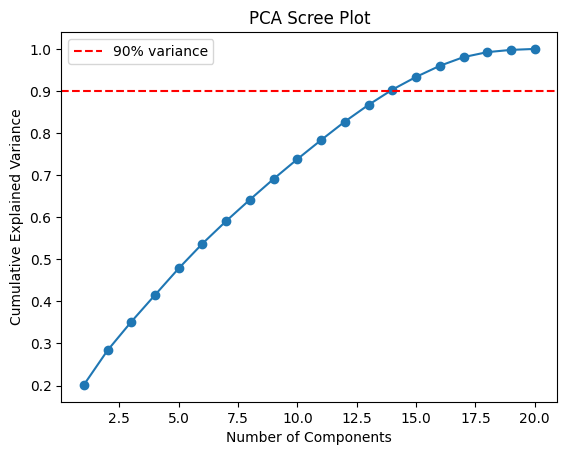

Components to explain 90% variance: 14


In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train)

# Scree plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label="90% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.legend()
plt.show()

print("Components to explain 90% variance:",
      sum(pca.explained_variance_ratio_.cumsum() < 0.90) + 1)

### Logistic Regression

- A statistical classification model that estimates the probability of an observation belonging to a category, in our case none, borderline, or diabetes, based on a set of input variables

- It works by fitting a curve to the data that maps predictor variables

- We use it as our baseline model because it is interpretable, meaning we can directly read the coefficients to understand which variables drive diabetes risk

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("CV Accuracy:", cross_val_score(log_reg, X_train, y_train, cv=10).mean().round(4))
print(classification_report(y_test, log_reg.predict(X_test)))

CV Accuracy: 0.6815
              precision    recall  f1-score   support

           0       0.51      0.55      0.53      1075
           1       0.47      0.17      0.25       324
           2       0.77      0.82      0.80      2125

    accuracy                           0.68      3524
   macro avg       0.58      0.51      0.52      3524
weighted avg       0.66      0.68      0.66      3524



### KNN
- A non-parametric model that classifies a new observation by finding the K most similar individuals in the training data and assigning the most common class among them
- It does not learn a fixed equation like logistic regression, instead it memorizes the training data and makes predictions based on proximity in feature space
- We use K=5, meaning each person is classified based on their 5 most similar counterparts across variables like age, BMI, and physical activity

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("CV Accuracy:", cross_val_score(knn, X_train, y_train, cv=10).mean().round(4))
print(classification_report(y_test, knn.predict(X_test)))

CV Accuracy: 0.6308
              precision    recall  f1-score   support

           0       0.47      0.56      0.51      1075
           1       0.30      0.15      0.20       324
           2       0.76      0.75      0.75      2125

    accuracy                           0.64      3524
   macro avg       0.51      0.49      0.49      3524
weighted avg       0.63      0.64      0.63      3524



## Ridge Regression

- A regularized version of logistic regression that adds an L2 penalty to the model, which shrinks all coefficients toward zero to reduce overfitting

- Unlike standard logistic regression, ridge keeps all variables in the model but penalizes large coefficients, making it more stable when predictors are correlated

- We use it to test whether penalizing large coefficients improves prediction accuracy over the standard logistic regression baseline

In [24]:
from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier()
ridge.fit(X_train, y_train)

print("CV Accuracy:", cross_val_score(ridge, X_train, y_train, cv=10).mean().round(4))
print(classification_report(y_test, ridge.predict(X_test)))

CV Accuracy: 0.6782
              precision    recall  f1-score   support

           0       0.50      0.57      0.53      1075
           1       0.53      0.03      0.05       324
           2       0.77      0.83      0.80      2125

    accuracy                           0.67      3524
   macro avg       0.60      0.47      0.46      3524
weighted avg       0.66      0.67      0.65      3524



### LASSO Regression

- A regularized classification model that applies an L1 penalty, which can shrink some variable coefficients completely to zero, removing them from the model

- Unlike ridge, LASSO performs automatic variable selection, keeping only the most important predictors and producing a simpler model

- We use it to identify whether a reduced set of variables can match or outperform the full logistic regression model in predicting diabetes status

In [25]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(penalty="l1", solver="saga", max_iter=5000, random_state=42)
lasso.fit(X_train, y_train)

print("CV Accuracy:", cross_val_score(lasso, X_train, y_train, cv=10).mean().round(4))
print(classification_report(y_test, lasso.predict(X_test)))

CV Accuracy: 0.681
              precision    recall  f1-score   support

           0       0.51      0.55      0.53      1075
           1       0.47      0.17      0.25       324
           2       0.77      0.82      0.80      2125

    accuracy                           0.68      3524
   macro avg       0.59      0.51      0.52      3524
weighted avg       0.67      0.68      0.66      3524



### Bootstrap

- A resampling technique that repeatedly draws random samples with replacement from the training data, fits a model on each sample, and evaluates it on the test set to build a distribution of accuracy scores

- It gives a more reliable estimate of model stability than a single train/test split by showing how much performance varies across different samples of the data
- We apply it to our best model, logistic regression, running 100 iterations and finding a stable mean accuracy of 67.5% with very low variance, confirming the model generalizes consistently

Bootstrap Mean Accuracy: 0.675
Bootstrap Std: 0.0019


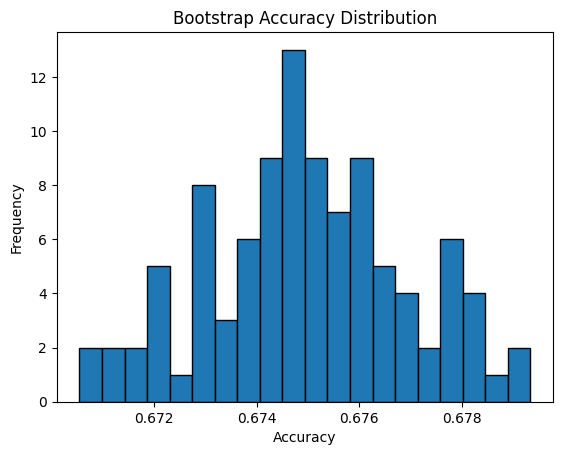

In [26]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

boot_scores = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_boot, y_boot)
    boot_scores.append(accuracy_score(y_test, model.predict(X_test)))

print("Bootstrap Mean Accuracy:", round(np.mean(boot_scores), 4))
print("Bootstrap Std:", round(np.std(boot_scores), 4))
plt.hist(boot_scores, bins=20, edgecolor='black')
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Bootstrap Accuracy Distribution")
plt.show()

## Feature Importance

Using Logistic Regression Coefficients:
- Logistic regression coefficients measure the relationship between each predictor variable and the outcome
- The size of the coefficient reflects how strongly a variable influences the prediction
- Unlike regular regression, logistic regression coefficients work on a log-odds scale, meaning they show how each variable shifts the probability of falling into each diabetes category (none, borderline, or diabetes)



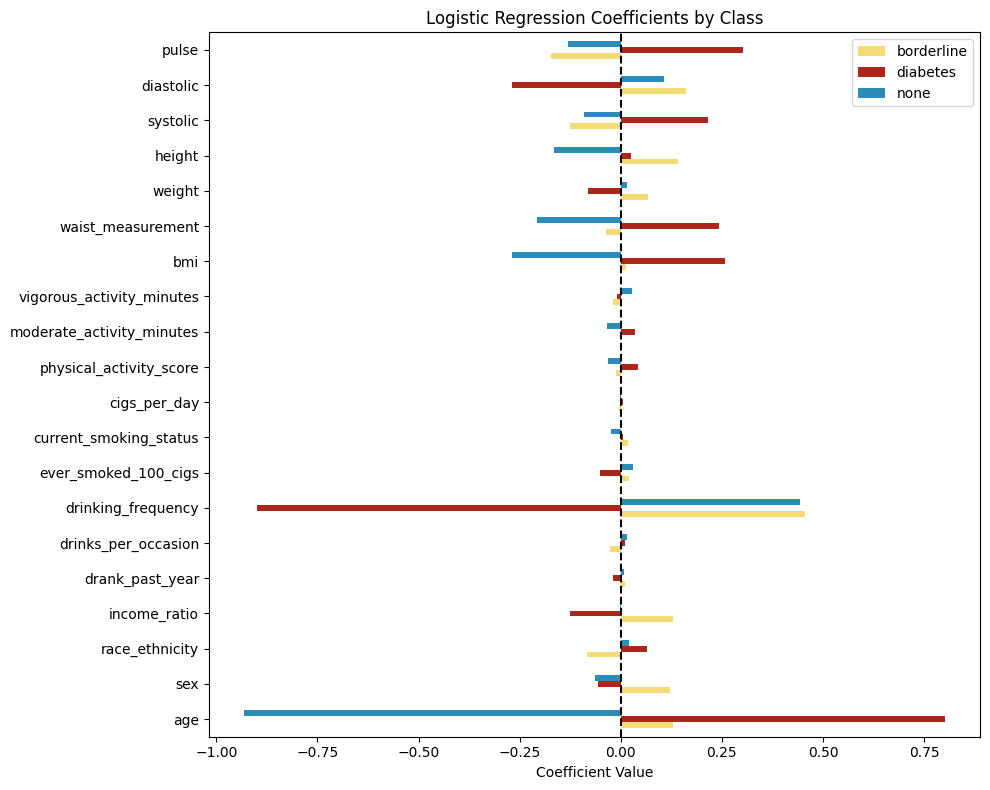

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns
coef_df = pd.DataFrame(log_reg.coef_.T, index=feature_names,
                        columns=["borderline", "diabetes", "none"])

coef_df.plot(kind="barh", figsize=(10, 8),
             color=["#F4DB76", "#AC261B", "#2D8BBA"])
plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Coefficient Value")
plt.axvline(x=0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

Using Random Forest Feature:
- Random Forest builds hundreds of decision trees and measures how much each variable improves the accuracy of splits across all trees, assigning an importance score to each predictor

- Unlike logistic regression coefficients, feature importance scores do not have a direction, they only tell you how much a variable matters overall, not whether it increases or decreases diabetes risk

- Random Forest is particularly useful here because it captures nonlinear relationships between predictors and the outcome that logistic regression may miss, giving a more complete picture of which variables are truly driving the classification

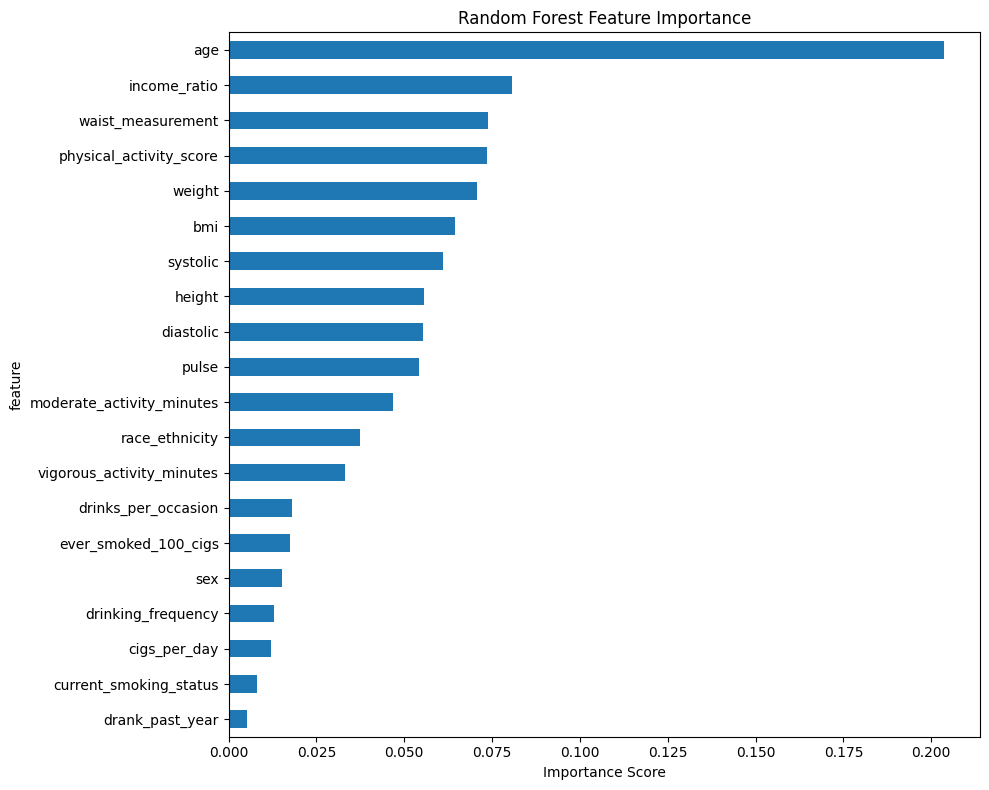

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

importance_df.plot(kind="barh", x="feature", y="importance",
                   figsize=(10, 8), legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Comparisons

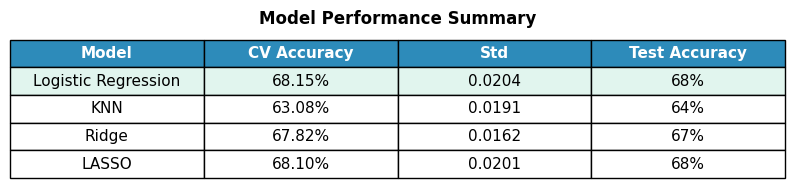

In [29]:
import matplotlib.pyplot as plt

results_data = {
    "Model": ["Logistic Regression", "KNN", "Ridge", "LASSO"],
    "CV Accuracy": ["68.15%", "63.08%", "67.82%", "68.10%"],
    "Std": ["0.0204", "0.0191", "0.0162", "0.0201"],
    "Test Accuracy": ["68%", "64%", "67%", "68%"]
}

df_results = pd.DataFrame(results_data)

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis("off")
table = ax.table(cellText=df_results.values,
                 colLabels=df_results.columns,
                 cellLoc="center",
                 loc="center")

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Header color
for j in range(len(df_results.columns)):
    table[0, j].set_facecolor("#2D8BBA")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Highlight best model
for j in range(len(df_results.columns)):
    table[1, j].set_facecolor("#E1F5EE")

plt.title("Model Performance Summary", fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

Logistic Regression: Mean=0.6815, Std=0.0204
KNN: Mean=0.6308, Std=0.0191
Ridge: Mean=0.6782, Std=0.0162
LASSO: Mean=0.681, Std=0.0201


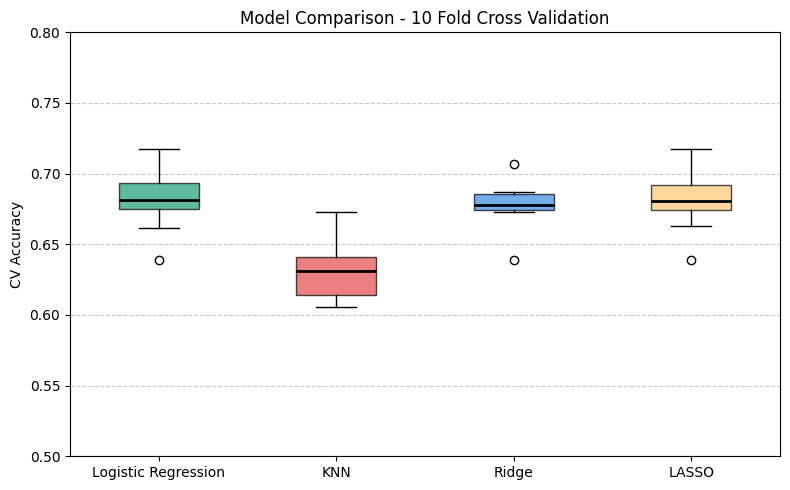

In [30]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Ridge": RidgeClassifier(),
    "LASSO": LogisticRegression(penalty="l1", solver="saga", max_iter=5000, random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10)
    cv_results[name] = scores
    print(f"{name}: Mean={scores.mean().round(4)}, Std={scores.std().round(4)}")

colors = ["#1D9E75", "#E24B4A", "#378ADD", "#FAC775"]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(cv_results.values(), tick_labels=cv_results.keys(), patch_artist=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

ax.set_ylabel("CV Accuracy")
ax.set_title("Model Comparison - 10 Fold Cross Validation")
ax.set_ylim(0.5, 0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Conclusion

Logistic Regression is the best model for your project because:

- Highest mean CV accuracy at 68.15%
- Reasonable standard deviation of 0.0204
- Simplest and most interpretable model